In [ ]:
!git clone https://github.com/mohamedaazouni10-code/ghostshot.git /content/ghostshot

Cloning into '/content/ghostshot'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 27 (delta 4), reused 23 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 9.95 KiB | 3.32 MiB/s, done.
Resolving deltas: 100% (4/4), done.


Cell 1: Boilerplate

In [ ]:
import sys, os
sys.path.insert(0, "/content/ghostshot")

# Mount Drive
from google.colab import drive
drive.mount("/content/drive")

# Go to repo
os.chdir("/content/ghostshot")

import yaml
from pathlib import Path

with open("configs/base.yaml") as f:
    cfg = yaml.safe_load(f)

from src.utils import set_seed, get_device
set_seed(cfg["project"]["seed"])
device = get_device(cfg)

print(f"Ready. Device = {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[seed] All random seeds set to 42
[device] Using configured device: cuda
Ready. Device = cuda


Cell 2: Install Dependencies

In [ ]:
!pip install -q timm torchvision \
  "albumentations>=1.4.15" \
  "scikit-learn>=1.5" \
  "wandb>=0.17" \
  "pandas>=2.2" \
  "matplotlib>=3.9" \
  "tqdm>=4.67" \
  "scipy>=1.13" \
  deepface facenet-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.4 MB/s eta 0:00:00


 Cell 3: Symlink Drive Storage

In [ ]:
import os
from pathlib import Path

os.chdir("/content/ghostshot")
DRIVE_ROOT = "/content/drive/MyDrive/ghostshot"

local_folders = [
    "data/raw", "data/processed", "data/attack_samples",
    "models/checkpoints", "results"
]
for f in local_folders:
    os.makedirs(f, exist_ok=True)

links = {
    f"{DRIVE_ROOT}/data/raw":            "data/raw",
    f"{DRIVE_ROOT}/data/processed":      "data/processed",
    f"{DRIVE_ROOT}/data/attack_samples": "data/attack_samples",
    f"{DRIVE_ROOT}/models/checkpoints":  "models/checkpoints",
    f"{DRIVE_ROOT}/results":             "results",
}

for drive_path, local_link in links.items():
    if os.path.islink(local_link):
        print(f"Already linked: {local_link}")
    elif os.path.isdir(local_link):
        os.rmdir(local_link)
        os.symlink(drive_path, local_link)
        print(f"Linked: {local_link} → {drive_path}")
    else:
        os.symlink(drive_path, local_link)
        print(f"Linked: {local_link} → {drive_path}")

Linked: data/raw → /content/drive/MyDrive/ghostshot/data/raw
Linked: data/processed → /content/drive/MyDrive/ghostshot/data/processed
Linked: data/attack_samples → /content/drive/MyDrive/ghostshot/data/attack_samples
Linked: models/checkpoints → /content/drive/MyDrive/ghostshot/models/checkpoints
Linked: results → /content/drive/MyDrive/ghostshot/results


Cell 4: Download Celeb-DF v2

Cell 5: Unzip Celeb-DF v2

In [ ]:
!unzip -q data/raw/celebdf_v2/Celeb-DF-v2.zip \
          -d data/raw/celebdf_v2/

!ls data/raw/celebdf_v2/

replace data/raw/celebdf_v2/Celeb-real/id0_0000.mp4? [y]es, [n]o, [A]ll, [N]one, [r]ename: A




Celeb-DF-v2.zip  Celeb-synthesis	     YouTube-real
Celeb-real	 List_of_testing_videos.txt


In [ ]:
!ls data/raw/celebdf_v2/

Celeb-DF-v2.zip  Celeb-synthesis	     YouTube-real
Celeb-real	 List_of_testing_videos.txt


 Cell 6: Check Video Counts

In [ ]:
import os
from pathlib import Path

for folder in ["Celeb-real", "Celeb-synthesis", "YouTube-real"]:
    path = Path(f"data/raw/celebdf_v2/{folder}")
    videos = list(path.glob("*.mp4"))
    print(f"{folder:<20}: {len(videos)} videos")

Celeb-real          : 590 videos
Celeb-synthesis     : 5639 videos
YouTube-real        : 148 videos


Cell 7: Run Face-Crop Pipeline on Real Videos

In [ ]:
from src.data.face_crop import process_dataset, write_manifest
from pathlib import Path

processed_dir = Path(cfg["data"]["processed_dir"])
manifest_rows = []

# Real videos — Celeb-real
process_dataset(
    raw_dir       = "data/raw/celebdf_v2/Celeb-real",
    processed_dir = processed_dir,
    dataset_name  = "celebdf_real",
    label         = 0,
    device        = device,
    manifest_rows = manifest_rows,
)

# Real videos — YouTube-real
process_dataset(
    raw_dir       = "data/raw/celebdf_v2/YouTube-real",
    processed_dir = processed_dir,
    dataset_name  = "youtube_real",
    label         = 0,
    device        = device,
    manifest_rows = manifest_rows,
)

print(f"\nTotal real videos processed: {len(manifest_rows)}")


Processing 'celebdf_real' — 590 videos, label=0


celebdf_real: 100%|██████████| 590/590 [26:16<00:00,  2.67s/it]



Processing 'youtube_real' — 148 videos, label=0


youtube_real: 100%|██████████| 148/148 [06:55<00:00,  2.81s/it]


Total real videos processed: 737


Cell 8: Run Face-Crop Pipeline on Fake Videos

In [ ]:
# Fake videos — Celeb-synthesis
process_dataset(
    raw_dir       = "data/raw/celebdf_v2/Celeb-synthesis",
    processed_dir = processed_dir,
    dataset_name  = "celebdf_fake",
    label         = 1,
    device        = device,
    manifest_rows = manifest_rows,
)

print(f"\nTotal videos processed: {len(manifest_rows)}")


Processing 'celebdf_fake' — 5639 videos, label=1


celebdf_fake:  40%|███▉      | 2252/5639 [2:00:03<2:34:37,  2.74s/it]

In [1]:
!git clone https://github.com/mohamedaazouni10-code/ghostshot.git /content/ghostshot

fatal: destination path '/content/ghostshot' already exists and is not an empty directory.


In [2]:
import sys, os
sys.path.insert(0, "/content/ghostshot")
os.chdir("/content/ghostshot")

from google.colab import drive
drive.mount("/content/drive")

import yaml
from pathlib import Path

with open("configs/base.yaml") as f:
    cfg = yaml.safe_load(f)

from src.utils import set_seed, get_device
set_seed(cfg["project"]["seed"])
device = get_device(cfg)
print(f"Ready. Device = {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[seed] All random seeds set to 42
[device] Using configured device: cuda
Ready. Device = cuda


In [3]:
!pip install -q timm torchvision \
  "albumentations>=1.4.15" \
  "scikit-learn>=1.5" \
  "wandb>=0.17" \
  "pandas>=2.2" \
  "matplotlib>=3.9" \
  "tqdm>=4.67" \
  "scipy>=1.13" \
  deepface facenet-pytorch

In [4]:
import os
from pathlib import Path

os.chdir("/content/ghostshot")
DRIVE_ROOT = "/content/drive/MyDrive/ghostshot"

local_folders = [
    "data/raw", "data/processed", "data/attack_samples",
    "models/checkpoints", "results"
]
for f in local_folders:
    os.makedirs(f, exist_ok=True)

links = {
    f"{DRIVE_ROOT}/data/raw":            "data/raw",
    f"{DRIVE_ROOT}/data/processed":      "data/processed",
    f"{DRIVE_ROOT}/data/attack_samples": "data/attack_samples",
    f"{DRIVE_ROOT}/models/checkpoints":  "models/checkpoints",
    f"{DRIVE_ROOT}/results":             "results",
}

for drive_path, local_link in links.items():
    if os.path.islink(local_link):
        print(f"Already linked: {local_link}")
    elif os.path.isdir(local_link):
        os.rmdir(local_link)
        os.symlink(drive_path, local_link)
        print(f"Linked: {local_link} → {drive_path}")
    else:
        os.symlink(drive_path, local_link)
        print(f"Linked: {local_link} → {drive_path}")

Already linked: data/raw
Already linked: data/processed
Already linked: data/attack_samples
Already linked: models/checkpoints
Already linked: results


In [16]:
from pathlib import Path

fake_dir = Path("data/processed/celebdf_fake")
if fake_dir.exists():
    folders = [f for f in fake_dir.rglob("*") if f.is_dir()]
    crops = list(fake_dir.rglob("*.png"))
    print(f"celebdf_fake: {len(folders)} videos, {len(crops)} crops")
else:
    print("celebdf_fake: nothing saved yet")

celebdf_real: 18771 crops
youtube_real: 4692 crops
celebdf_fake: 2265 videos, 71753 crops


In [5]:
from src.data.face_crop import get_mtcnn, sample_frames, crop_and_save
from pathlib import Path
from tqdm import tqdm

processed_dir = Path(cfg["data"]["processed_dir"])
raw_dir = Path("data/raw/celebdf_v2/Celeb-synthesis")
dataset_name = "celebdf_fake"
label = 1

# Get all videos
all_videos = [p for p in raw_dir.rglob("*") if p.suffix.lower() in (".mp4", ".avi", ".mov")]

# Find already processed ones
already_done = {d.name for d in (processed_dir / dataset_name / str(label)).iterdir() if d.is_dir()}

# Filter remaining
remaining = [v for v in all_videos if v.stem not in already_done]
print(f"Total videos : {len(all_videos)}")
print(f"Already done : {len(already_done)}")
print(f"Remaining    : {len(remaining)}")

# Process remaining
manifest_rows = []
mtcnn = get_mtcnn(device)

for vp in tqdm(remaining, desc="celebdf_fake"):
    identity_id = vp.stem
    out_dir = processed_dir / dataset_name / str(label) / identity_id
    frames  = sample_frames(str(vp))
    n_saved = crop_and_save(mtcnn, frames, out_dir, vp.stem)

    if n_saved > 0:
        manifest_rows.append({
            "identity_id":  identity_id,
            "dataset":      dataset_name,
            "label":        label,
            "crop_dir":     str(out_dir),
            "n_crops":      n_saved,
        })

print(f"\nNewly processed: {len(manifest_rows)} videos")

Total videos : 5639
Already done : 2264
Remaining    : 3375


AssertionError: Torch not compiled with CUDA enabled

In [8]:
!du -sh /content/drive/MyDrive/ghostshot/data/processed/*

2.8G	/content/drive/MyDrive/ghostshot/data/processed/celebdf_fake
752M	/content/drive/MyDrive/ghostshot/data/processed/celebdf_real
199M	/content/drive/MyDrive/ghostshot/data/processed/youtube_real


Step 3 — Write the manifest CSV.

In [9]:
from src.data.face_crop import write_manifest
from pathlib import Path
import pandas as pd

processed_dir = Path("data/processed")
manifest_rows = []

# Collect all processed datasets
datasets = {
    "celebdf_real": 0,
    "youtube_real": 0,
    "celebdf_fake": 1,
}

for dataset_name, label in datasets.items():
    dataset_dir = processed_dir / dataset_name / str(label)
    if not dataset_dir.exists():
        print(f"Skipping {dataset_name} — not found")
        continue
    for identity_dir in dataset_dir.iterdir():
        if not identity_dir.is_dir():
            continue
        crops = list(identity_dir.glob("*.png"))
        if crops:
            manifest_rows.append({
                "identity_id": identity_dir.name,
                "dataset":     dataset_name,
                "label":       label,
                "crop_dir":    str(identity_dir),
                "n_crops":     len(crops),
            })

manifest_path = Path("data/processed/manifest.csv")
write_manifest(manifest_rows, manifest_path)
print(f"Total entries: {len(manifest_rows)}")


Manifest written: data/processed/manifest.csv (2988 entries)
Total entries: 2988


Split into Train/Val/Test

In [10]:
from src.data.splitter import split_manifest, print_split_stats
from pathlib import Path

split_paths = split_manifest(
    manifest_path = Path("data/processed/manifest.csv"),
    out_dir       = Path("data/processed/splits"),
    train         = cfg["data"]["splits"]["train"],
    val           = cfg["data"]["splits"]["val"],
    test          = cfg["data"]["splits"]["test"],
    seed          = cfg["project"]["seed"],
)

print_split_stats(split_paths)

Manifest loaded: 2988 entries, 2988 unique identities
  train :  2091 entries | real=514 fake=1577 | 2091 identities
  val   :   448 entries | real=106 fake=342 | 448 identities
  test  :   449 entries | real=117 fake=332 | 449 identities

── Split statistics ─────────────────────────────────────
  train  → 2091 videos,  66597 crops, labels: {1: 1577, 0: 514}
  val    →  448 videos,  14299 crops, labels: {1: 342, 0: 106}
  test   →  449 videos,  14320 crops, labels: {1: 332, 0: 117}


Verify DataLoaders

/content/ghostshot/src/data/dataset.py:27: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=50, quality_upper=95, p=0.4),
/content/ghostshot/src/data/dataset.py:28: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=16,


  train  DataLoader:  16721 samples,  522 batches
  val    DataLoader:   3584 samples,  112 batches
  test   DataLoader:   3592 samples,  113 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch shape : torch.Size([32, 3, 224, 224])
Real in batch: 2
Fake in batch: 30


FileNotFoundError: [Errno 2] No such file or directory: 'results/figures/phase2_sample_crops.png'

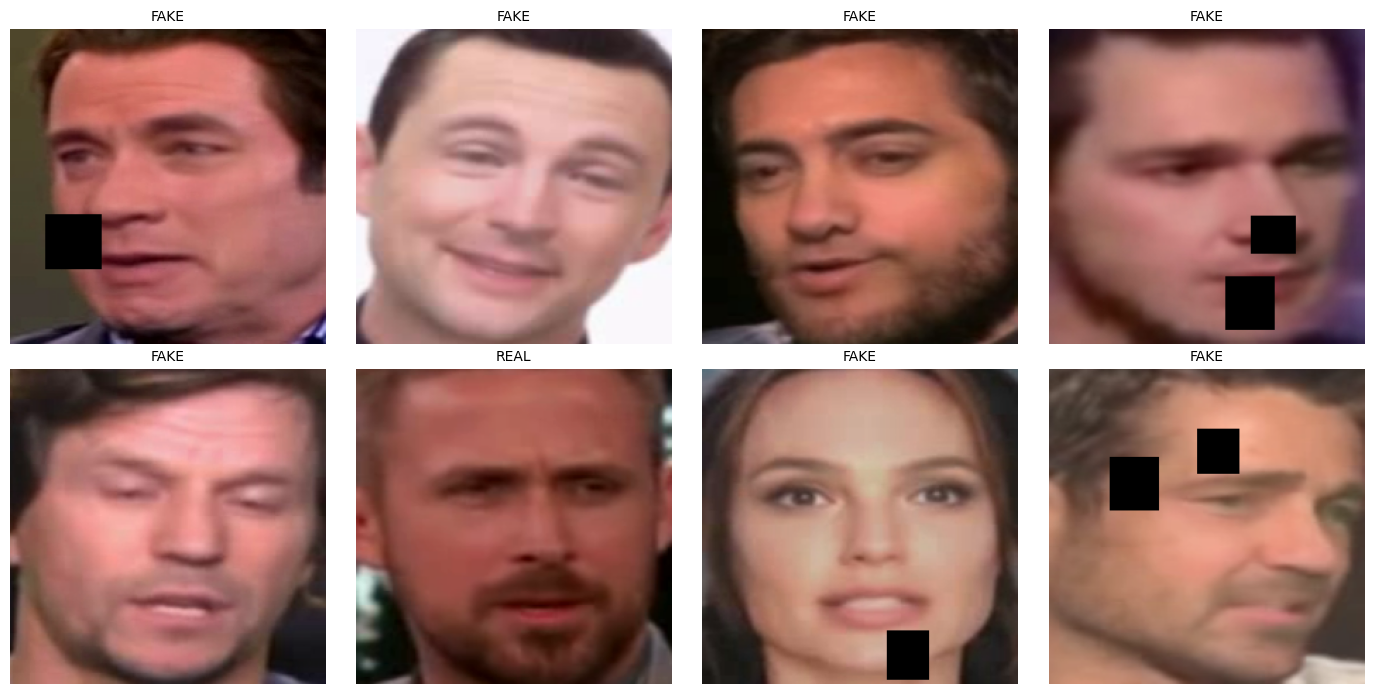

In [11]:
from src.data.dataset import build_dataloaders
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

loaders = build_dataloaders(split_paths, cfg)

# Grab one batch
batch = next(iter(loaders["train"]))
images = batch["image"]
labels = batch["label"]

print(f"Batch shape : {images.shape}")
print(f"Real in batch: {(labels==0).sum().item()}")
print(f"Fake in batch: {(labels==1).sum().item()}")

# Visualize 8 crops
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    ax.imshow(img)
    ax.set_title(f"{'REAL' if labels[i]==0 else 'FAKE'}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("results/figures/phase2_sample_crops.png", dpi=150)
plt.show()
print("✅ Sample crops saved!")

In [12]:
import os
os.makedirs("results/figures", exist_ok=True)

plt.tight_layout()
plt.savefig("results/figures/phase2_sample_crops.png", dpi=150)
plt.show()
print("✅ Sample crops saved!")

<Figure size 640x480 with 0 Axes>

✅ Sample crops saved!
